In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
import read_sim_not_clin_bg as rsnb

### Для просмотра файлов в папке

In [2]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021' # второй телескоп
folder_path = '/media/alexandra/DATA/IACT01_2020-2021' # первый телескоп

# Cписок файлов в папке
file_names = os.listdir(folder_path)

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [3]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021'
folder_path = '/media/alexandra/DATA/IACT01_2020-2021'
df_19 = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') # 19-год (один день)

# Cписок всех CSV-файлов в папке
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

# Читаем каждый файл и объединяем их в один DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]
hillas = pd.concat(dataframes, ignore_index=True)
combined_hillas = pd.concat([df_19, hillas], ignore_index=True)

hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


In [24]:
hillas.columns

Index(['por', 'event_numb', 'time', 'unix_time_ns', 'delta_time', 'error_deg',
       'tel_az', 'tel_el', 'source_az', 'source_el', 'CR400phe', 'CR_portion',
       'median_background', 'MAD_background', 'numb_pix', 'num_islands',
       'size', 'Xc', 'Yc', 'con_selected_island', 'con2', 'length', 'width',
       'dist1', 'dist2', 'a_axis', 'skewness_w', 'skewness_l', 'kurtosis_w',
       'kurtosis_l', 'alpha1', 'alpha2', 'tel_ra', 'tel_dec', 'source_ra',
       'source_dec', 'source_x', 'source_y', 'tracking', 'good', 'star',
       'edge', 'weather_mark', 'alpha_c'],
      dtype='object')

### Применяем каты

In [4]:
def filter_hillas_data(df):
    # Common filters for both source and anti-source
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    
    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(df_19)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
709,1,13650,16:00:10:513:944:670,1574524810513944670,0.01,0.03,118.95592,47.336,120.40375,48.035,...,22.01,0.99,-0.71,1,1,0,0.0,9.31,0.51,source
1574,2,26697,16:01:42:662:894:080,1574524902662894080,0.16,0.03,119.38536,47.540,120.84088,48.239,...,22.01,0.99,-0.71,1,1,1,0.0,9.36,0.51,source
2351,2,32070,16:02:53:749:452:180,1574524973749452180,0.25,0.03,119.71657,47.702,121.18010,48.397,...,22.01,0.99,-0.71,1,1,0,0.0,9.32,0.51,source
2360,2,32125,16:02:54:502:714:070,1574524974502714070,0.00,0.03,119.72204,47.703,121.18489,48.399,...,22.01,0.99,-0.71,1,1,0,0.0,9.32,0.51,source
2668,3,34895,16:03:34:464:161:100,1574525014464161100,0.04,0.03,119.91109,47.795,121.37673,48.487,...,22.01,0.99,-0.70,1,1,1,0.0,9.33,0.51,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204384,137,1980882,21:00:02:206:774:700,1574542802206774700,0.21,0.03,239.02795,48.301,237.52513,48.984,...,22.01,-1.00,-0.71,1,1,0,0.0,9.07,0.36,source
205056,137,1985258,21:01:12:396:970:200,1574542872396970200,0.40,0.03,239.36333,48.143,237.86575,48.831,...,22.01,-1.00,-0.72,1,1,0,0.0,9.05,0.35,source
205490,138,1988450,21:02:09:852:156:110,1574542929852156110,0.15,0.03,239.63636,48.013,238.14674,48.704,...,22.01,-0.99,-0.72,1,1,0,0.0,9.04,0.35,source
205740,138,1990099,21:02:35:978:715:980,1574542955978715980,0.02,0.03,239.75992,47.950,238.27234,48.647,...,22.01,-0.99,-0.72,1,1,1,0.0,9.03,0.35,source


### Гистограмма по тета

/tmp/ipykernel_5325/1845326320.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
/tmp/ipykernel_5325/1845326320.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 -


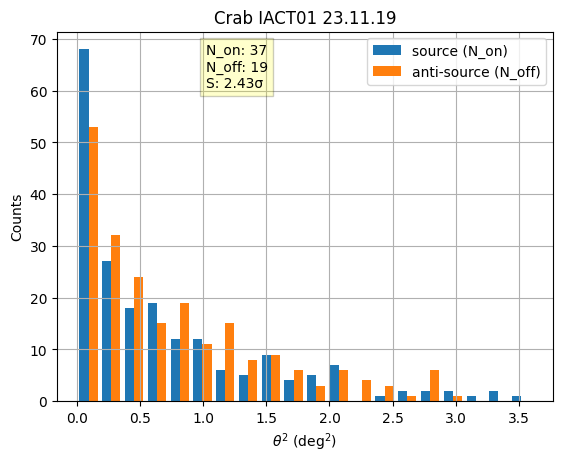

N_on = 37, N_off = 19, Significance = 2.43σ
        por  event_numb                  time         unix_time_ns  \
143       1        2805  15:59:15:694:170:230  1574524755694170230   
284       1        5427  15:59:28:817:664:770  1574524768817664770   
2416      2       32527  16:02:59:790:376:570  1574524979790376570   
3169      3       38332  16:04:19:892:378:820  1574525059892378820   
4658      4       49475  16:06:51:917:965:540  1574525211917965540   
...     ...         ...                   ...                  ...   
204464  137     1981434  21:00:11:056:770:090  1574542811056770090   
205056  137     1985258  21:01:12:396:970:200  1574542872396970200   
205821  138     1990529  21:02:43:038:505:770  1574542963038505770   
206528  138     1995005  21:03:56:986:529:370  1574543036986529370   
206592  138     1995382  21:04:03:121:594:380  1574543043121594380   

        delta_time  error_deg     tel_az  tel_el  source_az  source_el  ...  \
143           0.19       0.03  118.7

In [5]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=20, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Crab IACT01 23.11.19')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
plt.show()

print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')
print(antisource_events);

### Гистограмма по alpha

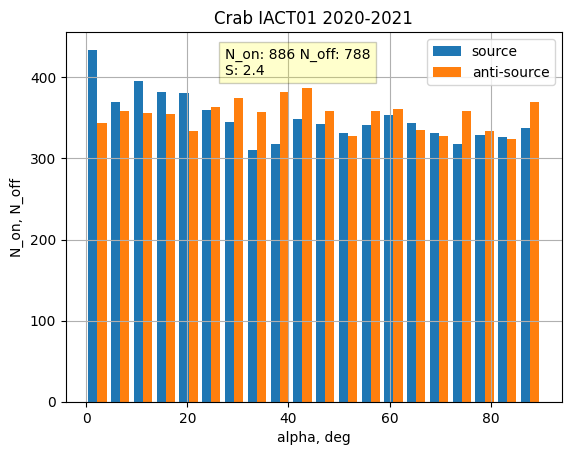

N_on = 886 N_off = 788 S_lima = 2.4


In [6]:
# та же самая функция, что выше только с доп катами, как у Паши В
# def filter_hillas_data(df):
#     common_filters = (
#         (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
#         (df['delta_time'] < 0.5) &
#         (df['error_deg'] < 0.1) &
#         (df['size'] > 120) &
#         (df['width'] > 0.024) &
#         (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
#         (df['length'] < 0.145 * np.log10(df['size']))
#     )
#     source_df = df[
#         common_filters &
#         (df['dist1'].between(0.36, 1.44))
#     ].copy()
#     source_df['source_type'] = 'source' 
    
#     anti_source_df = df[
#         common_filters &
#         (df['dist2'].between(0.36, 1.44))
#     ].copy()
#     anti_source_df['source_type'] = 'anti-source'
#     return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Crab IACT01 2020-2021') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

N_on = 431.0 N_off = 342.0 3.2011075056319482 3.2


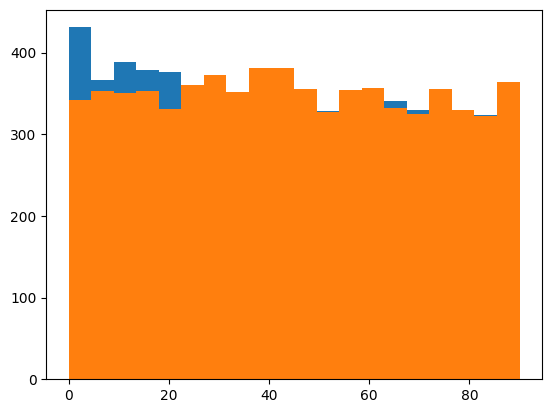

In [7]:
# Пашин В. вариант по альфа
# table_had = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') #23.11.19
table_had = hillas

on10 = plt.hist(table_had['alpha1'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist1'] > 0.36) & 
                      (table_had['dist1'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
off10 = plt.hist(table_had['alpha2'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist2'] > 0.36) & 
                      (table_had['dist2'] < 1.44) & 
                      (table_had['width'] > 0.024) & 

                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
N_on = on10[0]
N_off = off10[0]
S_lima = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
print('N_on =', on10[0], 'N_off =', off10[0], (on10[0] - off10[0])/np.sqrt(on10[0] + off10[0]), S_lima)

### Пересчитываем параметры для 5 точек фона

In [8]:
# Пересчитываем альфа и дисты
def add_background_alphas_dists_thetas_abs(df):
    df = df.copy()

    # Вектор от CoG до источника
    dx = df['source_x'] - df['Xc']
    dy = df['source_y'] - df['Yc']
    v_angle = np.arctan2(dy, dx)  # угол в радианах

    # Направление главной оси эллипса: от вектора на источник - alpha1
    u_angle = np.arctan(df.a_axis)  # главная ось в радианах
    u_x = np.cos(u_angle)
    u_y = np.sin(u_angle)

    # Расстояние от центра камеры до источника — радиус окружности
    r = np.sqrt(df['source_x']**2 + df['source_y']**2)

    # Угол на источник из центра камеры
    angle0 = np.arctan2(df['source_y'], df['source_x'])

    angles_deg = [180, 60, 120, 240, 300] # антиисточник и 4 новых фоновых
    angles_rad = [angle0 + np.deg2rad(a) for a in angles_deg]

    for i, angle in enumerate(angles_rad, start=1):
        # Координаты точки на окружности
        x = r * np.cos(angle)
        y = r * np.sin(angle)

        dx = x - df['Xc']
        dy = y - df['Yc']
        dist = np.sqrt(dx**2 + dy**2)

        v_angle = np.arctan2(dy, dx)
        delta = np.abs(v_angle - u_angle)
        delta = np.mod(delta, 2 * np.pi)
        alpha = np.minimum(delta, 2 * np.pi - delta)
        alpha_deg = np.rad2deg(alpha)
        alpha_deg = np.where(alpha_deg > 90, 180 - alpha_deg, alpha_deg)

        df[f'bg{i}_dist'] = dist
        df[f'bg{i}_alpha'] = alpha_deg
    return df

hillas_with_5point_background = add_background_alphas_dists_thetas_abs(df_19)

# print(hillas_with_4point_background.alpha2)
# print(hillas_with_4point_background.bg2_alpha)
hillas_with_5point_background

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
0,1,14,15:59:01:558:835:010,1574524741558835010,0.44,0.03,118.64135,47.181,120.08002,47.882,...,2.993505,30.742728,1.710993,12.713154,2.689995,6.745096,2.525370,54.347491,1.438374,70.943584
1,1,24,15:59:01:633:642:980,1574524741633642980,0.37,0.03,118.64135,47.181,120.08002,47.882,...,3.134929,3.925016,2.458472,46.123345,3.191035,26.109246,2.309597,15.245488,1.093445,12.651943
2,1,28,15:59:01:654:668:020,1574524741654668020,0.35,0.03,118.64135,47.181,120.08002,47.882,...,1.593976,85.198787,3.598047,69.345200,2.469148,60.532004,2.415383,68.293360,3.561366,76.376565
3,1,30,15:59:01:669:731:650,1574524741669731650,0.33,0.03,118.64135,47.181,120.08002,47.882,...,2.194866,89.397081,2.337169,35.212260,1.400075,60.064607,3.343174,81.987772,3.831313,64.044964
4,1,40,15:59:01:704:527:060,1574524741704527060,0.30,0.03,118.64135,47.181,120.08002,47.882,...,2.864050,58.097060,3.970227,89.002475,3.822641,71.144662,1.715550,68.616111,2.023175,74.497163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206599,138,1995440,21:04:04:093:403:660,1574543044093403660,4.59,0.03,240.15575,47.771,238.67420,48.464,...,3.502538,37.113689,1.709132,63.841087,2.300172,32.473267,4.107930,53.237847,3.808599,70.496699
206600,138,1995450,21:04:04:246:995:490,1574543044246995490,4.75,0.03,240.15575,47.771,238.67420,48.464,...,3.695208,26.812126,1.575185,27.563848,2.713434,40.071887,3.881351,8.428777,3.191139,8.087469
206601,138,1995453,21:04:04:280:441:380,1574543044280441380,4.78,0.03,240.15575,47.771,238.67420,48.464,...,2.092023,59.109267,0.793447,39.738487,1.643397,85.117808,1.995287,24.357051,1.382018,12.847317
206602,138,1995454,21:04:04:291:544:180,1574543044291544180,4.79,0.03,240.15575,47.771,238.67420,48.464,...,3.002931,72.636367,1.348587,34.160301,2.474597,49.265266,2.758010,83.308749,1.817051,63.164801


### Рисуем выбранные точки

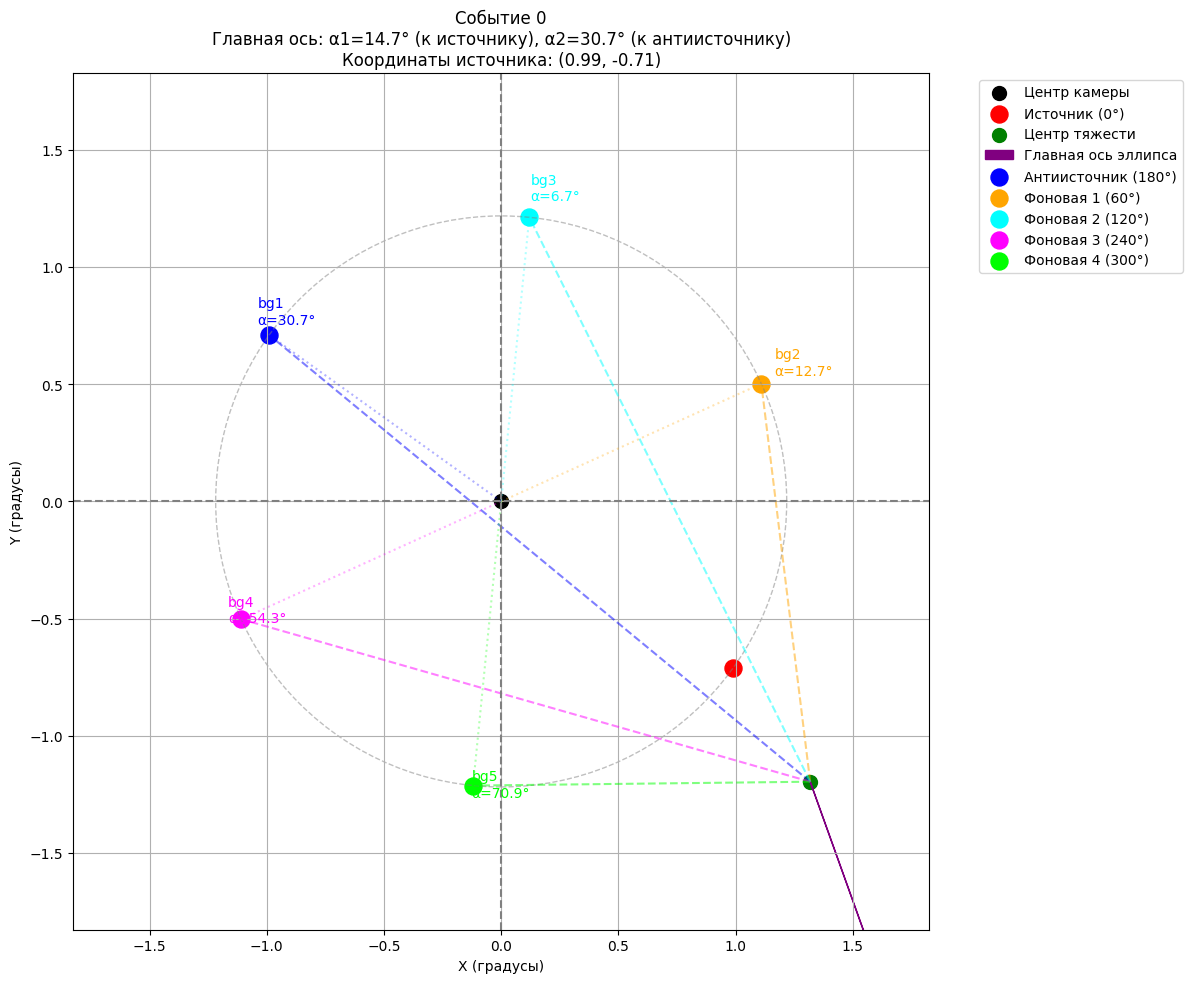

In [9]:
def visualize_5_background_points(df, event_index=0):
    """Визуализация 5 фоновых точек для конкретного события"""
    event = df.iloc[event_index]
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Центр камеры
    ax.scatter(0, 0, color='black', s=100, label='Центр камеры')
    
    # Координаты источника (0°)
    ax.scatter(event['source_x'], event['source_y'], color='red', s=150, label='Источник (0°)')
    
    # Центр тяжести события (CoG)
    ax.scatter(event['Xc'], event['Yc'], color='green', s=100, label='Центр тяжести')
    
    # Главная ось эллипса
    axis_length = 2.0
    angle_rad = np.arctan(event['a_axis'])
    dx = axis_length * np.cos(angle_rad)
    dy = axis_length * np.sin(angle_rad)
    ax.arrow(event['Xc'], event['Yc'], dx, dy, 
             head_width=0.1, head_length=0.2, fc='purple', ec='purple', 
             label='Главная ось эллипса')

    # Углы для фоновых точек [0, 180, 60, 120, 240, 300] - 0° это источник
    angles_deg = [180, 60, 120, 240, 300]  # 5 фоновых точек
    bg_colors = ['blue', 'orange', 'cyan', 'magenta', 'lime']
    bg_labels = ['Антиисточник (180°)', 'Фоновая 1 (60°)', 
                 'Фоновая 2 (120°)', 'Фоновая 3 (240°)', 
                 'Фоновая 4 (300°)']
    
    # Радиус окружности (расстояние от центра до источника)
    r = np.sqrt(event['source_x']**2 + event['source_y']**2)
    
    # Угол источника
    angle0 = np.arctan2(event['source_y'], event['source_x'])
    
    for i, (angle_deg, color, label) in enumerate(zip(angles_deg, bg_colors, bg_labels), start=1):
        angle_rad = angle0 + np.deg2rad(angle_deg)
        
        # Координаты фоновой точки
        bg_x = r * np.cos(angle_rad)
        bg_y = r * np.sin(angle_rad)
        
        # Линия от центра камеры к точке
        ax.plot([0, bg_x], [0, bg_y], color=color, linestyle=':', alpha=0.3)
        
        # Фоновая точка
        ax.scatter(bg_x, bg_y, color=color, s=150, label=label)
        
        # Линия от CoG к фоновой точке
        ax.plot([event['Xc'], bg_x], [event['Yc'], bg_y], 
                color=color, linestyle='--', alpha=0.5)
        
        # Подпись точки
        ax.text(bg_x*1.05, bg_y*1.05, f'bg{i}\nα={event[f"bg{i}_alpha"]:.1f}°', 
                color=color, ha='left', va='bottom')

    # Окружность через источник
    circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', alpha=0.5)
    ax.add_patch(circle)
    
    # Настройки графика
    ax.set_xlim(-r*1.5, r*1.5)
    ax.set_ylim(-r*1.5, r*1.5)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlabel('X (градусы)')
    ax.set_ylabel('Y (градусы)')
    
    title = (f"Событие {event_index}\n"
             f"Главная ось: α1={event['alpha1']:.1f}° (к источнику), "
             f"α2={event['alpha2']:.1f}° (к антиисточнику)\n"
             f"Координаты источника: ({event['source_x']:.2f}, {event['source_y']:.2f})")
    ax.set_title(title)
    
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

visualize_5_background_points(hillas_with_5point_background, 0)

### Накладываем каты

In [10]:
def filter_hillas_data_split_background(df):
    # Общие фильтры
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    # Таблица с источником (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ]
    # Отдельные таблицы для каждого фонового региона
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ]
    bg2_df = df[
        common_filters &
        (df['bg2_dist'].between(0.36, 1.44))
    ]
    bg3_df = df[
        common_filters &
        (df['bg3_dist'].between(0.36, 1.44))
    ]
    bg4_df = df[
        common_filters &
        (df['bg4_dist'].between(0.36, 1.44))
    ]
    bg5_df = df[
        common_filters &
        (df['bg5_dist'].between(0.36, 1.44))
    ]
    return source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df

source, anti_source, bg2, bg3, bg4, bg5 = filter_hillas_data_split_background(hillas_with_5point_background)
bg2

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
709,1,13650,16:00:10:513:944:670,1574524810513944670,0.01,0.03,118.95592,47.336,120.40375,48.035,...,3.049251,61.680315,1.042029,40.640755,2.260172,41.315282,3.076513,84.617389,2.332891,74.631097
2360,2,32125,16:02:54:502:714:070,1574524974502714070,0.00,0.03,119.72204,47.703,121.18489,48.399,...,2.130779,61.693789,1.365318,47.905457,2.010563,84.247428,1.691095,26.866580,0.825549,15.677904
2416,2,32527,16:02:59:790:376:570,1574524979790376570,0.21,0.03,119.74931,47.715,121.21124,48.411,...,1.196809,16.718393,1.365224,85.993702,0.153937,77.663407,2.163596,9.915353,2.553681,38.338432
2470,2,32907,16:03:05:049:806:740,1574524985049806740,0.45,0.03,119.77112,47.724,121.23760,48.423,...,1.496535,43.535428,0.889330,80.290797,0.353379,79.099483,2.240622,12.659238,2.384621,17.890626
2668,3,34895,16:03:34:464:161:100,1574525014464161100,0.04,0.03,119.91109,47.795,121.37673,48.487,...,1.797992,75.006282,0.651242,33.760302,1.316622,32.604740,1.850050,66.202231,1.453722,25.305798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202290,135,1964824,20:56:07:377:941:940,1574542567377941940,0.12,0.03,234.82607,50.140,236.37200,49.492,...,3.152643,46.134360,1.359666,76.987640,1.971478,39.596062,3.735445,64.004590,3.451886,82.940275
203339,136,1974078,20:58:03:755:013:010,1574542683755013010,0.24,0.03,238.46056,48.585,236.94721,49.240,...,2.479765,84.146961,1.185737,26.743022,2.115803,54.986680,2.179724,66.668132,1.296358,38.227438
204968,137,1984823,21:01:05:140:972:140,1574542865140972140,0.14,0.03,239.32911,48.159,237.83176,48.847,...,2.980375,3.529519,0.871663,8.202062,1.938310,19.256080,3.318278,18.190095,2.830851,39.469022
205056,137,1985258,21:01:12:396:970:200,1574542872396970200,0.40,0.03,239.36333,48.143,237.86575,48.831,...,1.276997,53.839719,1.126695,1.050157,1.170650,65.891270,1.337925,2.330541,1.299640,58.011280


### Вычисляем тета

In [11]:
def calculate_theta2_for_all_separate(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df):
    def calculate_ksi(rc, size):
        """Функция для расчета коэффициента ksi"""
        if rc < 7.5:
            return 1.3
        elif rc <= 10:
            return 1.6
        else:
            if size < 700:
                return 2.0
            elif size < 1000:
                return 1.9
            elif size < 1250:
                return 1.75
            elif size < 1500:
                return 1.5
        return np.nan

    # 1. Обработка источника
    source_processed = source_df.copy()
    if 'dist1' in source_processed.columns:
        source_processed['source_rc'] = source_processed['dist1'] / 0.1206
        source_processed['source_ksi'] = source_processed.apply(
            lambda row: calculate_ksi(row['source_rc'], row['size']), axis=1)
        source_processed = source_processed[~source_processed['source_ksi'].isna()]  # Remove NaN values
        source_processed['source_disp'] = source_processed['source_ksi'] * (
            1.0 - source_processed['width'] / source_processed['length'])
        source_processed['source_theta2'] = (
            source_processed['source_disp']**2 + 
            source_processed['dist1']**2 - 
            2 * source_processed['source_disp'] * source_processed['dist1'] * 
            np.cos(np.radians(source_processed['alpha1'])))
        
        source_processed = source_processed.drop(
            columns=['source_rc', 'source_ksi', 'source_disp'], errors='ignore')

    # 2. Обработка антиисточника
    anti_source_processed = anti_source_df.copy()
    if 'dist2' in anti_source_processed.columns:
        anti_source_processed['dist2_rc'] = anti_source_processed['dist2'] / 0.1206
        anti_source_processed['dist2_ksi'] = anti_source_processed.apply(
            lambda row: calculate_ksi(row['dist2_rc'], row['size']), axis=1)
        anti_source_processed = anti_source_processed[~anti_source_processed['dist2_ksi'].isna()]  # Remove NaN value
        anti_source_processed['dist2_disp'] = anti_source_processed['dist2_ksi'] * (
            1.0 - anti_source_processed['width'] / anti_source_processed['length'])
        anti_source_processed['dist2_theta2'] = (
            anti_source_processed['dist2_disp']**2 + 
            anti_source_processed['dist2']**2 - 
            2 * anti_source_processed['dist2_disp'] * anti_source_processed['dist2'] * 
            np.cos(np.radians(anti_source_processed['alpha2']))) # это тета просто так подписано)) 
        
        anti_source_processed = anti_source_processed.drop(
            columns=['dist2_rc', 'dist2_ksi', 'dist2_disp'], errors='ignore')

    # 3-6. Обработка 4 фоновых точек (bg2, bg3, bg4, bg5)
    def process_bg(df, bg_num):
        """Обработка одной фоновой точки"""
        df = df.copy()
        prefix = f'bg{bg_num}_'
        
        df[f'{prefix}rc'] = df[f'{prefix}dist'] / 0.1206
        df[f'{prefix}ksi'] = df.apply(
            lambda row: calculate_ksi(row[f'{prefix}rc'], row['size']), axis=1)
        df = df[~df[f'{prefix}ksi'].isna()]  # Remove NaN values
        df[f'{prefix}disp'] = df[f'{prefix}ksi'] * (1.0 - df['width'] / df['length'])
        # print(df[f'{prefix}disp'])
        df[f'{prefix}theta2'] = (
            df[f'{prefix}disp']**2 + 
            df[f'{prefix}dist']**2 - 
            2 * df[f'{prefix}disp'] * df[f'{prefix}dist'] * 
            np.cos(np.radians(df[f'{prefix}alpha'])))
        
        return df.drop(columns=[f'{prefix}rc', f'{prefix}ksi', f'{prefix}disp'], errors='ignore')

    bg2_processed = process_bg(bg2_df, 2)
    bg3_processed = process_bg(bg3_df, 3)
    bg4_processed = process_bg(bg4_df, 4)
    bg5_processed = process_bg(bg5_df, 5)

    return (
        source_processed,
        anti_source_processed,
        bg2_processed,
        bg3_processed,
        bg4_processed,
        bg5_processed
    )

(source_processed, 
 anti_source_processed,
 bg2_processed,
 bg3_processed, 
 bg4_processed,
 bg5_processed) = calculate_theta2_for_all_separate(source, anti_source, bg2, bg3, bg4, bg5)
anti_source_processed[['event_numb', 'dist2_theta2']]

,event_numb,dist2_theta2
143,2805,0.237974
284,5427,0.269219
2416,32527,0.129038
3169,38332,0.212511
4658,49475,0.006422
...,...,...
204464,1981434,1.094953
205056,1985258,1.211964
205821,1990529,0.435620
206528,1995005,1.107999


### Совмещенное распределение фона

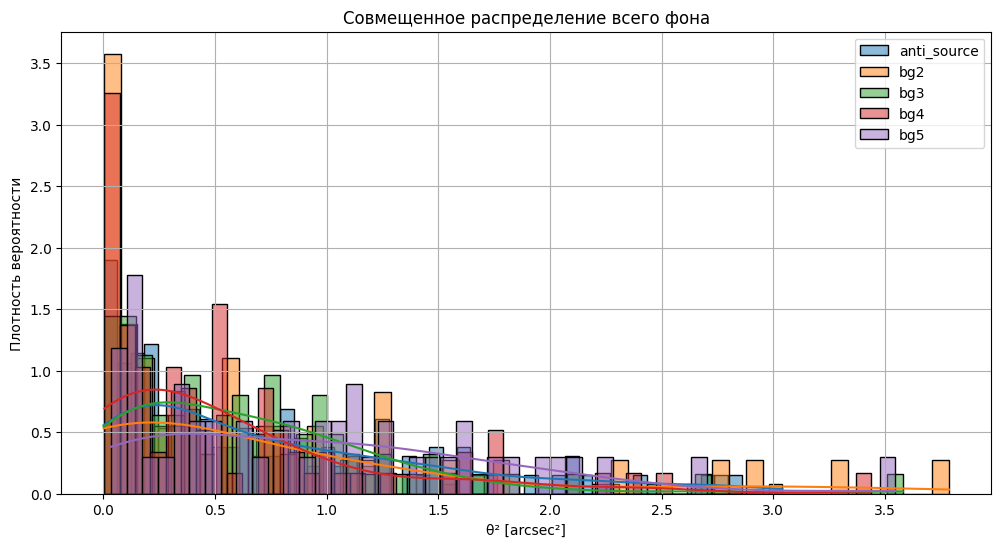

In [12]:
import seaborn as sns

# Собираем все данные в один DataFrame
all_data = pd.DataFrame()

# Добавляем антиисточник (если у него есть theta2)
if 'dist2_theta2' in anti_source_processed.columns:
    all_data['anti_source'] = anti_source_processed['dist2_theta2']

# Добавляем фоновые точки
for i, bg_df in enumerate([bg2_processed, bg3_processed, bg4_processed, bg5_processed], 2):
    col_name = f'bg{i}_theta2'
    if col_name in bg_df.columns:
        all_data[f'bg{i}'] = bg_df[col_name]

# Построение гистограмм
plt.figure(figsize=(12, 6))

# Гистограмма для каждого набора данных
for column in all_data.columns:
    sns.histplot(all_data[column], 
                 bins=50, 
                 alpha=0.5, 
                 label=column,
                 kde=True,
                 stat='density')

plt.title('Совмещенное распределение всего фона')
plt.xlabel('θ² [arcsec²]')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()

### 5 точек фона и источник

[31.  21.2 17.  12.6 12.4 10.6  8.2  9.8  8.6  7.6  9.2  6.2  6.8  7.4
  6.4  3.   6.6  3.   2.   3.   1.8  5.   1.8  1.6  1.6  2.   2.2  2.8
  1.   1.6  1.   1.4  0.8  0.8  0.4  1.6  1.2  0.6  0.4  0.4  0.2  0.4
  0.2  0.8  0.   0.4  0.4  0.2  0.   0.2]


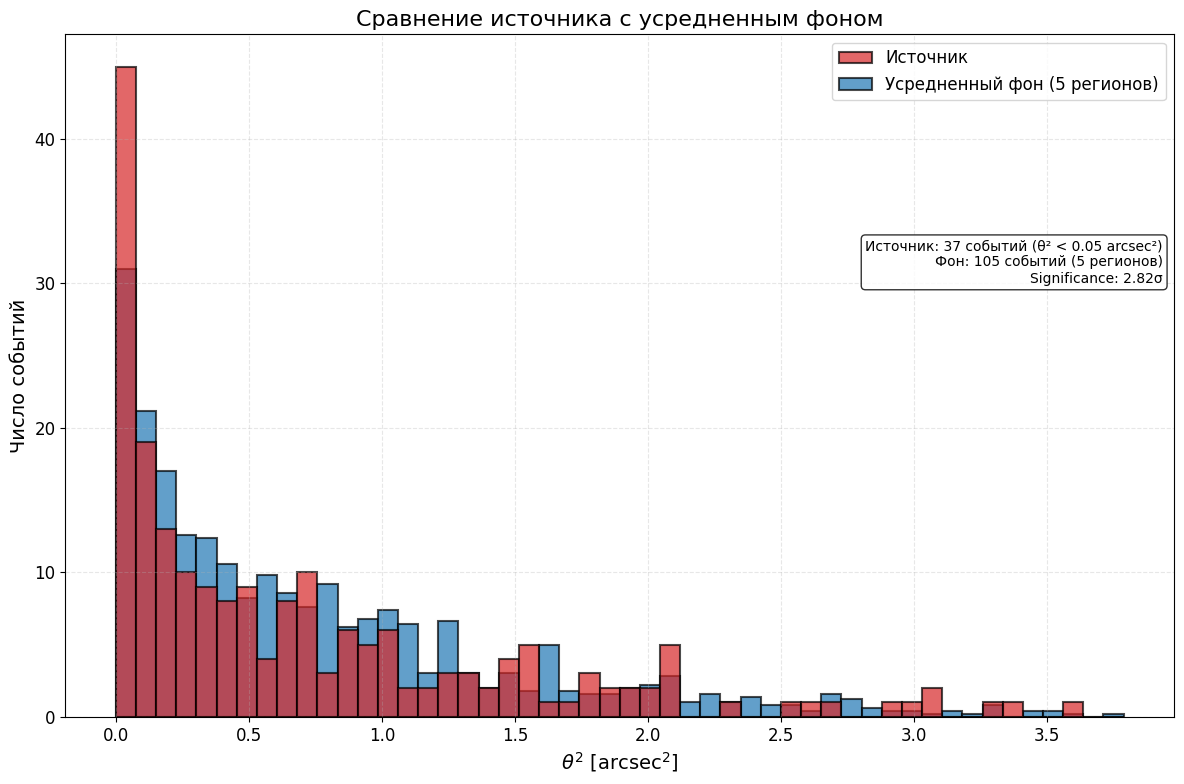

In [13]:
def plot_combined_with_averaged_background(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=40, theta_cut=None):
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna(),
        bg5_df['bg5_theta2'].dropna()
    ]

    # Данные источника
    source_data = source_df['source_theta2'].dropna()

    # Параметры гистограмм
    hist_kwargs = {
        'alpha': 0.7,
        'linewidth': 1.5,
        'edgecolor': 'k'
    }

    # Общие бины для всех гистограмм
    bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
    
    # Гистограмма источника (для визуализации)
    source_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Усредненная гистограмма фона (только для визуализации)
    background_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
    background_hist_avg = np.mean(background_hists, axis=0)
    print(background_hist_avg)

    # Визуализация
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.bar(bin_centers, background_hist_avg, width=np.diff(bin_edges), 
            color='#1f77b4', label='Усредненный фон (5 регионов)', **hist_kwargs)
    plt.hist(source_data, bins=bin_edges, color='#d62728', label='Источник', **hist_kwargs)

    ### Исправленный расчет значимости ###
    N_on = np.sum(source_data < theta_cut)
    
    # Суммируем все фоновые события до усреднения!
    N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
    alpha = 1/5 
    
    # Формула Ли-Ма 
    term1 = N_on * np.log((1 + alpha)/alpha * (N_on/(N_on + N_off_total)))
    term2 = N_off_total * np.log((1 + alpha) * (N_off_total/(N_on + N_off_total)))
    S = np.sqrt(2 * (term1 + term2)) 
    S = round(S, 2)

    # Добавляем статистику
    stats_text = "\n".join([
        f"Источник: {N_on} событий (θ² < {theta_cut} arcsec²)",
        f"Фон: {N_off_total} событий (5 регионов)",
        f"Significance: {S}σ"
    ])

    plt.annotate(stats_text, xy=(0.99, 0.7), xycoords='axes fraction',
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('Число событий', fontsize=14)
    plt.title('Сравнение источника с усредненным фоном', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    # plt.yscale('log')
    plt.tight_layout()
    plt.show()

# Вызов функции для построения графика
plot_combined_with_averaged_background(
    source_processed,
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed,
    bins=50,
    theta_cut=0.05 
)

## Эффективная площадь

### Моделирование

In [14]:
# с хилласом (триггер телескопа)
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv'
sim_hill_599 = pd.read_csv(file_simulation)
# изначальное моделирование
file_sim = '/home/alexandra/Desktop/TAIGA/taiga599_A_sums2'
sim_all_599 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_599

,A,xtet,ytet,dist,AI,N_b_f,col7,col8,col9,col10,E_sim
0,888.892653,-3.51,534.416625,457.058225,439.579895,26.482924,13,-4.703607e-07,4.231571e-09,182.74090,2.151626
1,426.677352,-4.05,534.416625,732.247448,724.916617,16.233526,6,-3.843284e-07,7.019448e-09,129.27460,2.151626
2,1637.371427,-2.65,534.416625,955.281722,905.770323,57.675601,27,-1.066398e-06,7.605068e-09,400.36240,2.151626
3,1599.630920,-2.50,534.416625,706.148852,674.070373,51.276230,20,-7.637558e-07,3.680620e-09,301.48820,2.151626
4,4667.930916,-4.20,534.416625,731.925923,651.853182,157.899416,92,-1.190169e-06,2.359231e-09,1136.49400,2.151626
...,...,...,...,...,...,...,...,...,...,...,...
1999395,384.900603,-3.51,604.870563,525.646651,520.063037,12.719204,8,-5.698918e-07,1.238933e-08,104.89000,2.170609
1999396,157.851691,-4.05,604.870563,802.642012,802.577479,5.572622,0,NaN,NaN,25.45542,2.170609
1999397,212.506364,-2.65,604.870563,1021.630625,1000.233137,6.370202,2,-9.504681e-07,1.024259e-13,68.91426,2.170609
1999398,234.647820,-2.50,604.870563,773.627600,761.357519,6.125054,3,-7.461413e-07,2.282230e-09,24.78345,2.170609


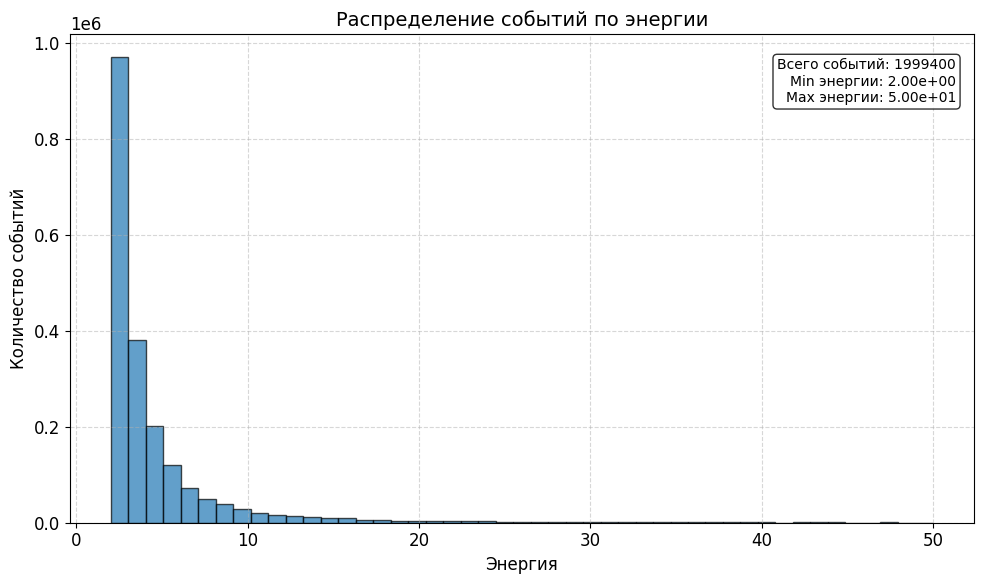

In [16]:
# проверка диапазона по энергии
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_all_599['E_sim'].min()
energy_max = sim_all_599['E_sim'].max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_all_599['E_sim'], bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_all_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

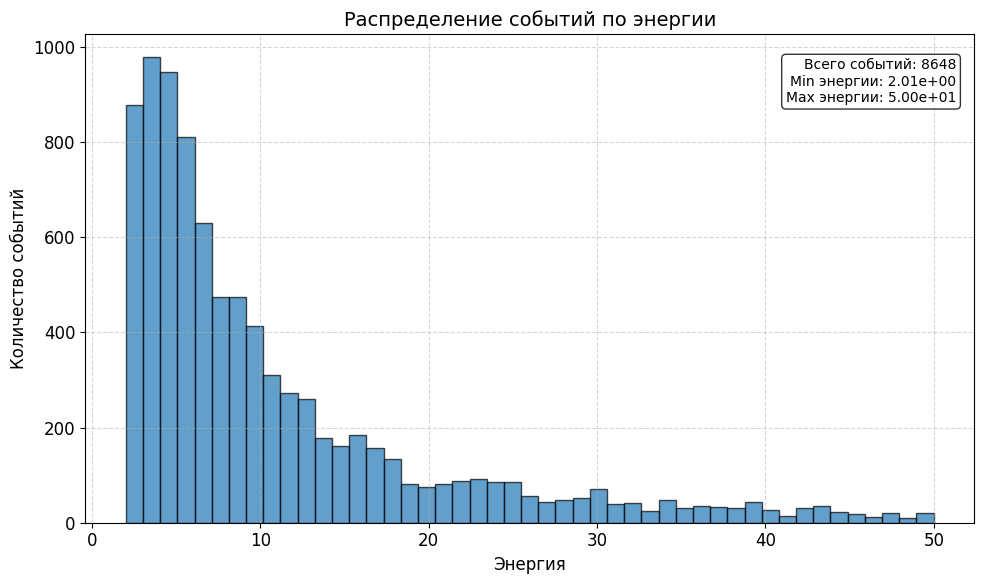

In [17]:
# проверка диапазона по энергии из телескопа
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_hill_599.energy.min()
energy_max = sim_hill_599.energy.max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_hill_599.energy, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_hill_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [21]:
sim_hill_599.columns

Index(['clean_number', 'event_number', 'axis_scatter', 'numb_pix', 'energy',
       'size', 'Xc[0]', 'Yc[0]', 'con2', 'length[0]', 'width[0]', 'dist[0]',
       'dist[1]', 'azwidth[1]', 'miss[1]', 'alpha[0]', 'alpha[1]', 'a_axis[0]',
       'b_axis[0]', 'x_max_coord', 'y_max_coord', 'skewness_l', 'kurtosis_l',
       'skewness_w', 'kurtosis_w', 'con1', 'con3', 'edge', 'source_x',
       'source_y', 'x_ground', 'y_ground', 'tel_tet', 'tel_fi', 'source_tet',
       'source_fi', 'Xmax', 'num_islands', 'con_selected_island'],
      dtype='object')

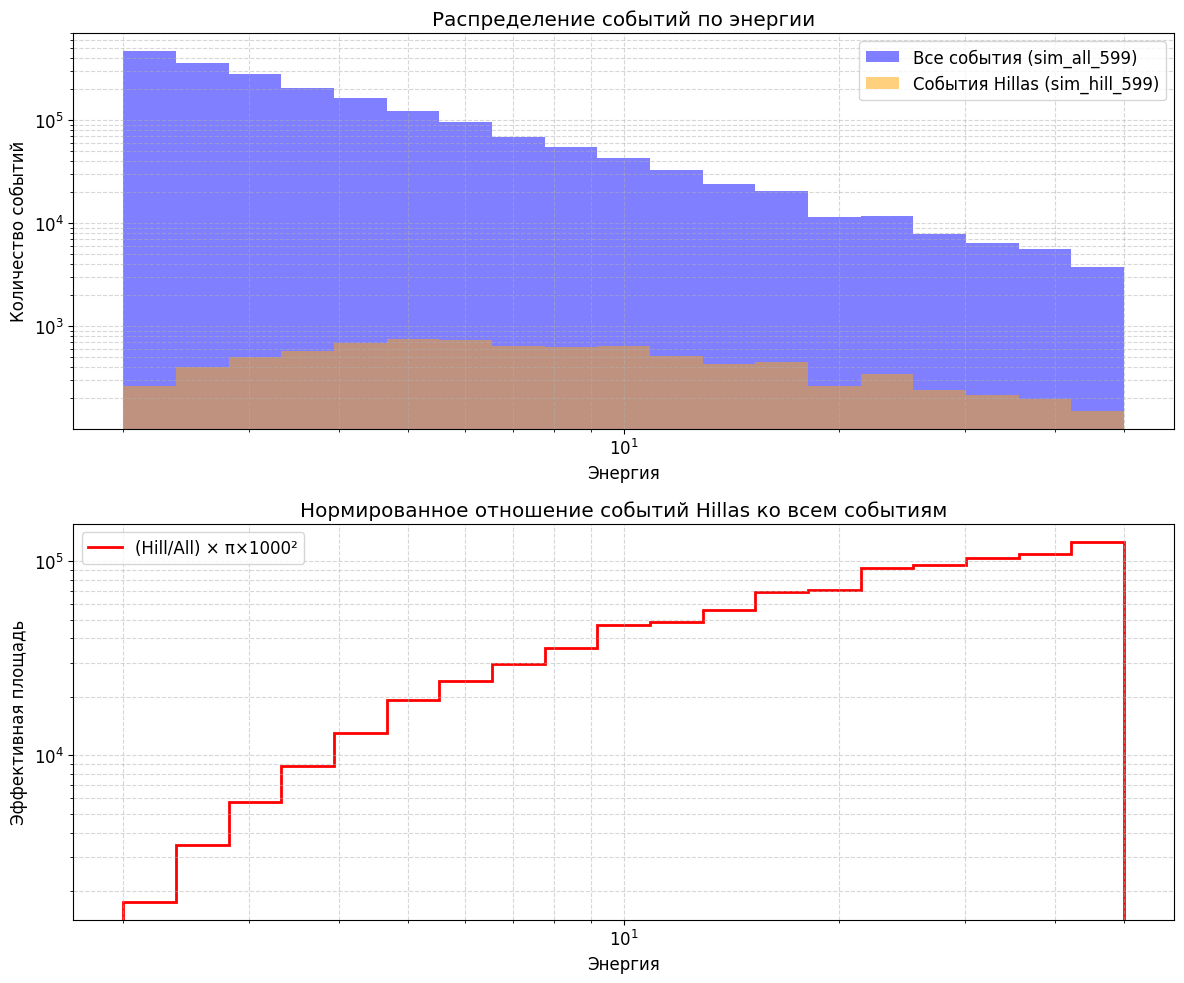

In [19]:
df_all = sim_all_599 
df_hill = sim_hill_599 

# Определение диапазона энергий (логарифмические бины)
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)  # 20 логарифмических бинов

# Расчет гистограмм
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)

# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle  # Защита от деления на 0

# Построение графиков
plt.figure(figsize=(12, 10))

# 1. Распределения по энергии
plt.subplot(2, 1, 1)
plt.stairs(hist_all, bin_edges, label='Все события (sim_all_599)', fill=True, alpha=0.5, color='blue')
plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_599)', fill=True, alpha=0.5, color='orange')
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия')
plt.ylabel('Количество событий')
plt.title('Распределение событий по энергии')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# 2. Отношение 
plt.subplot(2, 1, 2)
plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия')
plt.ylabel('Эффективная площадь')
plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('energy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
def filter_hillas_data(df):
    common_filters = (
        (df['size'] > 120) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
    )
    
    source_df = df[
        common_filters &
        (df['dist[0]'].between(0.36, 1.44))
    ]
    
    return source_df

sim_hill_selected_599 = filter_hillas_data(sim_hill_599)
sim_hill_selected_599

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
5,5,31,5,10,19.41840,856.251,0.930775,0.295348,0.542173,0.308242,...,0.862707,-61.9193,12.85120,0.662259,2.84144,0.647056,2.86593,391.042,1,1.0
7,7,42,8,4,13.85630,393.941,0.918508,0.868309,0.846906,0.132539,...,0.862810,-12.6554,-4.16856,0.546353,2.85816,0.531109,2.88714,305.828,1,1.0
23,23,98,6,8,20.65240,423.841,-0.270941,0.885689,0.612154,0.310477,...,0.862786,1.9727,188.56400,0.587970,3.09875,0.572742,3.12590,343.661,1,1.0
25,25,100,0,4,6.11845,135.324,0.877505,0.151807,0.816862,0.221335,...,0.862680,-195.9550,103.37200,0.712000,2.67637,0.696811,2.69941,258.214,1,1.0
34,34,161,7,7,15.12130,471.021,0.698418,0.584535,0.836500,0.173198,...,0.862752,-42.8872,26.98610,0.658054,3.11005,0.642849,3.13467,355.141,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8605,8605,39765,5,8,7.63018,330.642,-0.086281,0.577536,0.682215,0.332646,...,0.862792,62.8003,133.30600,0.599830,2.36532,0.584606,2.39200,358.274,1,1.0
8608,8608,39792,4,4,4.58679,183.533,0.215978,0.659881,0.893959,0.193620,...,0.862793,-20.9939,96.66290,0.568941,2.93022,0.553706,2.95817,397.795,1,1.0
8621,8621,39865,0,5,9.29708,205.359,0.006497,0.657389,0.749463,0.209359,...,0.862783,50.3945,167.49000,0.602353,2.57026,0.587130,2.59684,311.248,1,1.0
8634,8634,39899,6,6,8.17348,348.505,0.938103,0.036507,0.630384,0.271669,...,0.862820,-144.4360,11.31080,0.549348,2.98182,0.534105,3.01065,360.602,1,1.0


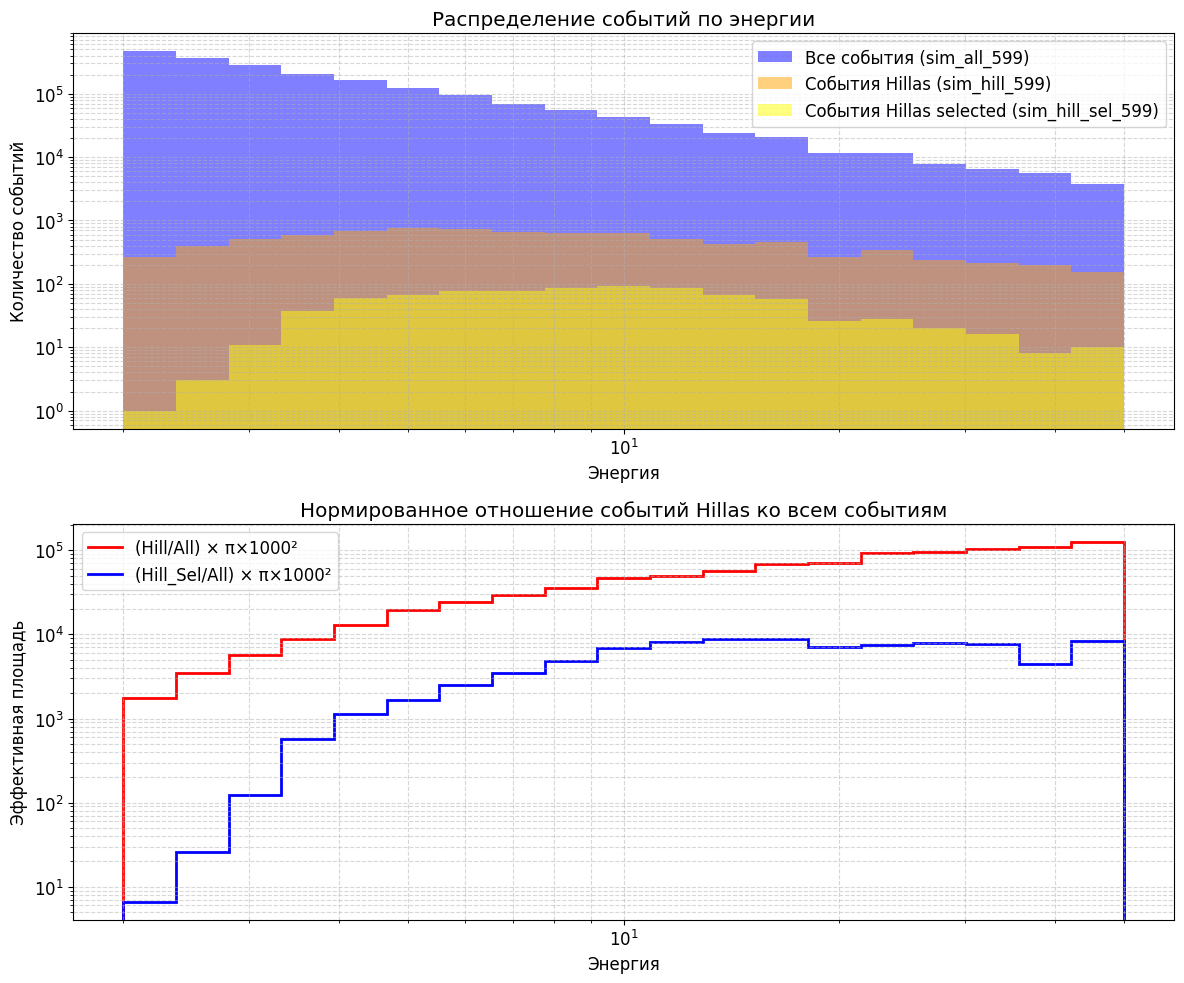

In [31]:
df_all = sim_all_599 
df_hill = sim_hill_599 
df_hill_sel = sim_hill_selected_599

# Определение диапазона энергий (логарифмические бины)
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)  # 20 логарифмических бинов

# Расчет гистограмм
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)
hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges)


# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle

# Построение графиков
plt.figure(figsize=(12, 10))

# 1. Распределения по энергии
plt.subplot(2, 1, 1)
plt.stairs(hist_all, bin_edges, label='Все события (sim_all_599)', fill=True, alpha=0.5, color='blue')
plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_599)', fill=True, alpha=0.5, color='orange')
plt.stairs(hist_hill_sel, bin_edges, label='События Hillas selected (sim_hill_sel_599)', fill=True, alpha=0.5, color='yellow')
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия')
plt.ylabel('Количество событий')
plt.title('Распределение событий по энергии')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# 2. Отношение 
plt.subplot(2, 1, 2)
plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.stairs(ratio_sel, bin_edges, label='(Hill_Sel/All) × π×1000²', color='blue', linewidth=2)
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия')
plt.ylabel('Эффективная площадь')
plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eff_sq_all_599.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# суммарно 19 год добавить (после того, как Паша обработает)
# эффективную площадь построить (с отобранными)
# unfolding